# SVM Multiclasse : Prétraitement, Entraînement et Évaluation

## Import des librairies

In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

## Chargement des données

In [32]:
df = pd.read_csv("data/Crop_Recommendation.csv")
df.head()


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice


## Inspection générale

In [33]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   pH_Value     2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Crop         2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Rainfall       0
Crop           0
dtype: int64

## Inspection des Données

L’ensemble de données contient **2200 observations** et **8 variables**, dont **7 caractéristiques numériques** et **1 variable cible** (`Crop`).  
Les premières inspections montrent que la base est **propre** : aucune valeur manquante n’est détectée et les types de données sont correctement définis.

### Détail des Colonnes

| Colonne       | Type      | Description |
|---------------|-----------|-------------|
| `Nitrogen`     | int64    | Quantité d'azote dans le sol |
| `Phosphorus`   | int64    | Quantité de phosphore |
| `Potassium`    | int64    | Quantité de potassium |
| `Temperature`  | float64  | Température (°C) |
| `Humidity`     | float64  | Humidité (%) |
| `pH_Value`     | float64  | Niveau de pH du sol |
| `Rainfall`     | float64  | Pluviométrie |
| `Crop`         | object   | Type de culture (variable cible) |

### Vérification des valeurs manquantes

Aucune valeur manquante n’a été détectée.


Cet ensemble de données est donc **directement exploitable** pour la suite :  
analyse exploratoire, visualisations, encodage de la variable cible et construction d’un modèle SVM.

### Remarque générale

Les caractéristiques représentent des paramètres agro-climatiques mesurables, cohérents et bien formatés.  
Cela laisse présager qu’un modèle de classification, notamment un **SVM**, pourra capter des patterns intéressants pour prédire la culture (`Crop`) à partir des attributs du sol et du climat.




## Nombre de classes et équilibrage

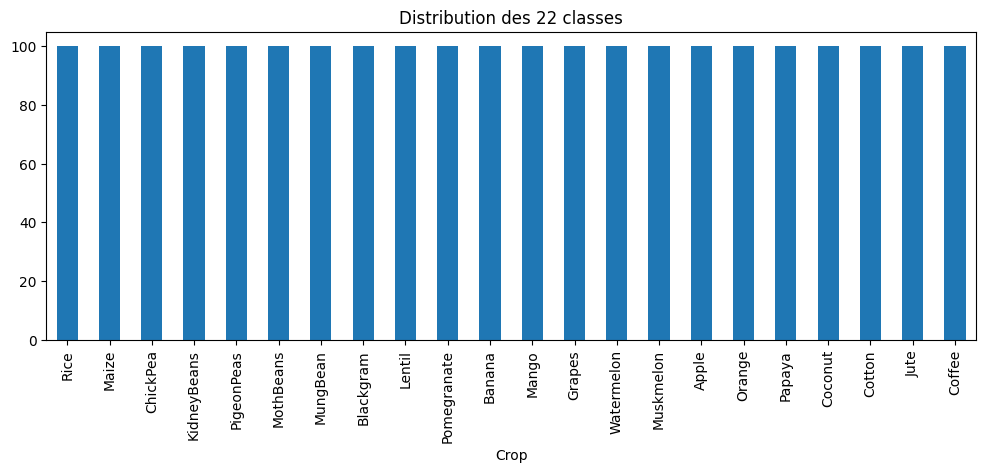

In [34]:
df['Crop'].value_counts()
df['Crop'].value_counts().plot(kind='bar', figsize=(12,4))
plt.title("Distribution des 22 classes")
plt.show()

## Distribution de la variable cible `Crop`

L’inspection de la distribution des 22 classes montre que chaque culture possède environ **100 observations**.  
Cela signifie que l’ensemble de données est **parfaitement équilibré**, sans classe majoritaire ni classe minoritaire.

### Ce que cela implique

- Aucun risque de biais du modèle en faveur d’une classe.
- Pas besoin d’utiliser de techniques de rééquilibrage (oversampling, undersampling, SMOTE).
- L’accuracy reste une métrique fiable pour l’évaluation.
- Le modèle SVM pourra apprendre les frontières décisionnelles de manière équitable pour l'ensemble des cultures.

### Conclusion

Cet équilibre des classes constitue un **excellent point de départ** pour un problème de classification multiclasse.  
Le modèle pourra se concentrer sur la séparation des classes sans être perturbé par des déséquilibres structurels dans les données.


## Séparation X / y

## Séparation des variables explicatives (X) et de la variable cible (y)

Pour préparer l’entraînement du modèle de classification, les données ont été séparées en :

- **X** : l’ensemble des **variables explicatives**, c’est-à-dire les caractéristiques agro-climatiques utilisées pour prédire la culture.
- **y** : la **variable cible**, correspondant au type de culture (`Crop`). 

Cette séparation permet de fournir au modèle d’apprentissage supervisé les données nécessaires :  
 - X pour apprendre les relations entre les caractéristiques du sol et du climat,  
 - y pour apprendre à associer ces caractéristiques à la culture correspondante.


In [35]:
X = df.drop("Crop", axis=1)
y = df["Crop"]

# Visualisation des données avec TSNE

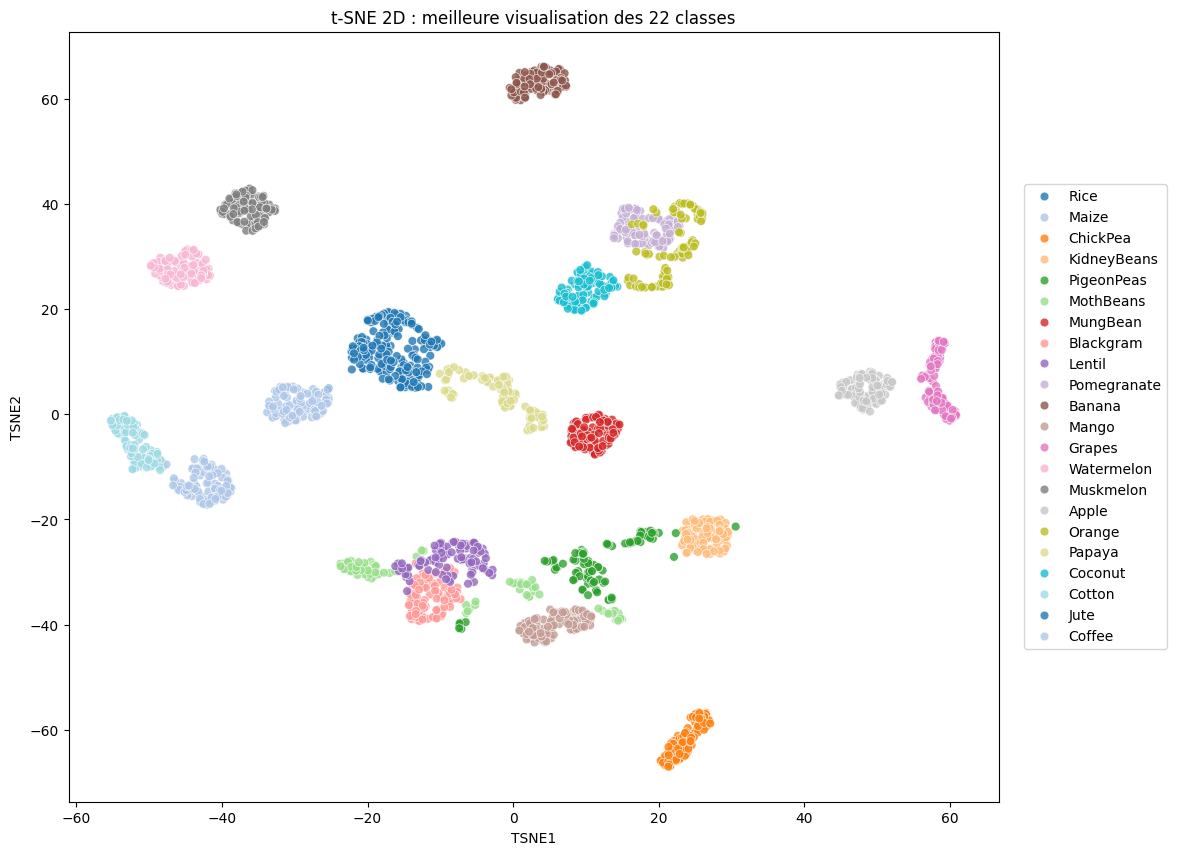

In [36]:
# ============================
# VISUALISATION t-SNE 2D
# ============================

# Scaling obligatoire avant t-SNE
scaler_tsne = StandardScaler()
X_scaled_tsne = scaler_tsne.fit_transform(X)

# t-SNE 2D
tsne_2d = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate=200,
    random_state=42
)

X_tsne_2d = tsne_2d.fit_transform(X_scaled_tsne)

df_tsne = pd.DataFrame({
    "TSNE1": X_tsne_2d[:, 0],
    "TSNE2": X_tsne_2d[:, 1],
    "Crop": y
})

plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=df_tsne,
    x="TSNE1",
    y="TSNE2",
    hue="Crop",
    palette="tab20",
    s=40,
    alpha=0.8
)

plt.title("t-SNE 2D : meilleure visualisation des 22 classes")
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.show()


## Visualisation des données avec t-SNE (2D)

Pour mieux comprendre la structure des données, une réduction de dimension a été effectuée à l’aide de **t-SNE** afin de projeter les 22 classes dans un espace bidimensionnel.

### Observations principales

- Les **22 cultures apparaissent sous forme de clusters distincts**, montrant que les paramètres du sol et du climat permettent de bien différencier les cultures.
- Certains groupes sont **très compacts** (ex : Coconut, Coffee, Grapes), ce qui indique des profils agro-climatiques clairement définis.
- D’autres clusters sont **plus proches ou légèrement étirés** (ex : les légumineuses : MothBeans, MungBean, Blackgram, Lentil), ce qui traduit une certaine similarité entre leurs caractéristiques.
- Malgré ces légères proximités, les classes restent globalement **bien séparées**, confirmant que le problème est **favorable à une classification supervisée**.

### Conclusion

Le t-SNE montre que les données sont **structurellement bien organisées**, avec des groupes naturels visibles.  
Cela suggère qu’un modèle comme le **SVM** pourra tirer avantage de cette organisation pour obtenir de bonnes performances en classification multiclasse.


## Train / Test split

## Séparation des données en ensembles d’entraînement et de test

Après la préparation des données, l’ensemble a été divisé en deux parties :  
- **Ensemble d’entraînement (train)** : utilisé pour apprendre les relations entre les variables explicatives et la variable cible.  
- **Ensemble de test (test)** : utilisé pour évaluer les performances du modèle sur des données jamais vues.

La séparation a été réalisée avec un `test_size` de 20 %, ce qui garantit :

- un volume d’entraînement suffisant pour apprendre correctement les frontières décisionnelles du SVM ;
- un ensemble de test représentatif pour mesurer la capacité du modèle à généraliser.

Grâce à l’équilibre des classes dans le dataset, cette répartition conserve la même proportion de cultures dans les deux ensembles, assurant une évaluation fiable et non biaisée.


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SVM brute

           SVM SANS PENALISATION       

Accuracy : 0.9840909090909091

Classification report :
               precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        20
      Banana       1.00      1.00      1.00        20
   Blackgram       1.00      1.00      1.00        20
    ChickPea       1.00      1.00      1.00        20
     Coconut       1.00      1.00      1.00        20
      Coffee       1.00      1.00      1.00        20
      Cotton       0.91      1.00      0.95        20
      Grapes       1.00      1.00      1.00        20
        Jute       0.87      1.00      0.93        20
 KidneyBeans       0.95      1.00      0.98        20
      Lentil       1.00      1.00      1.00        20
       Maize       1.00      0.90      0.95        20
       Mango       0.95      1.00      0.98        20
   MothBeans       1.00      0.95      0.97        20
    MungBean       1.00      1.00      1.00        20
   Muskmelon       1.00      1.00     

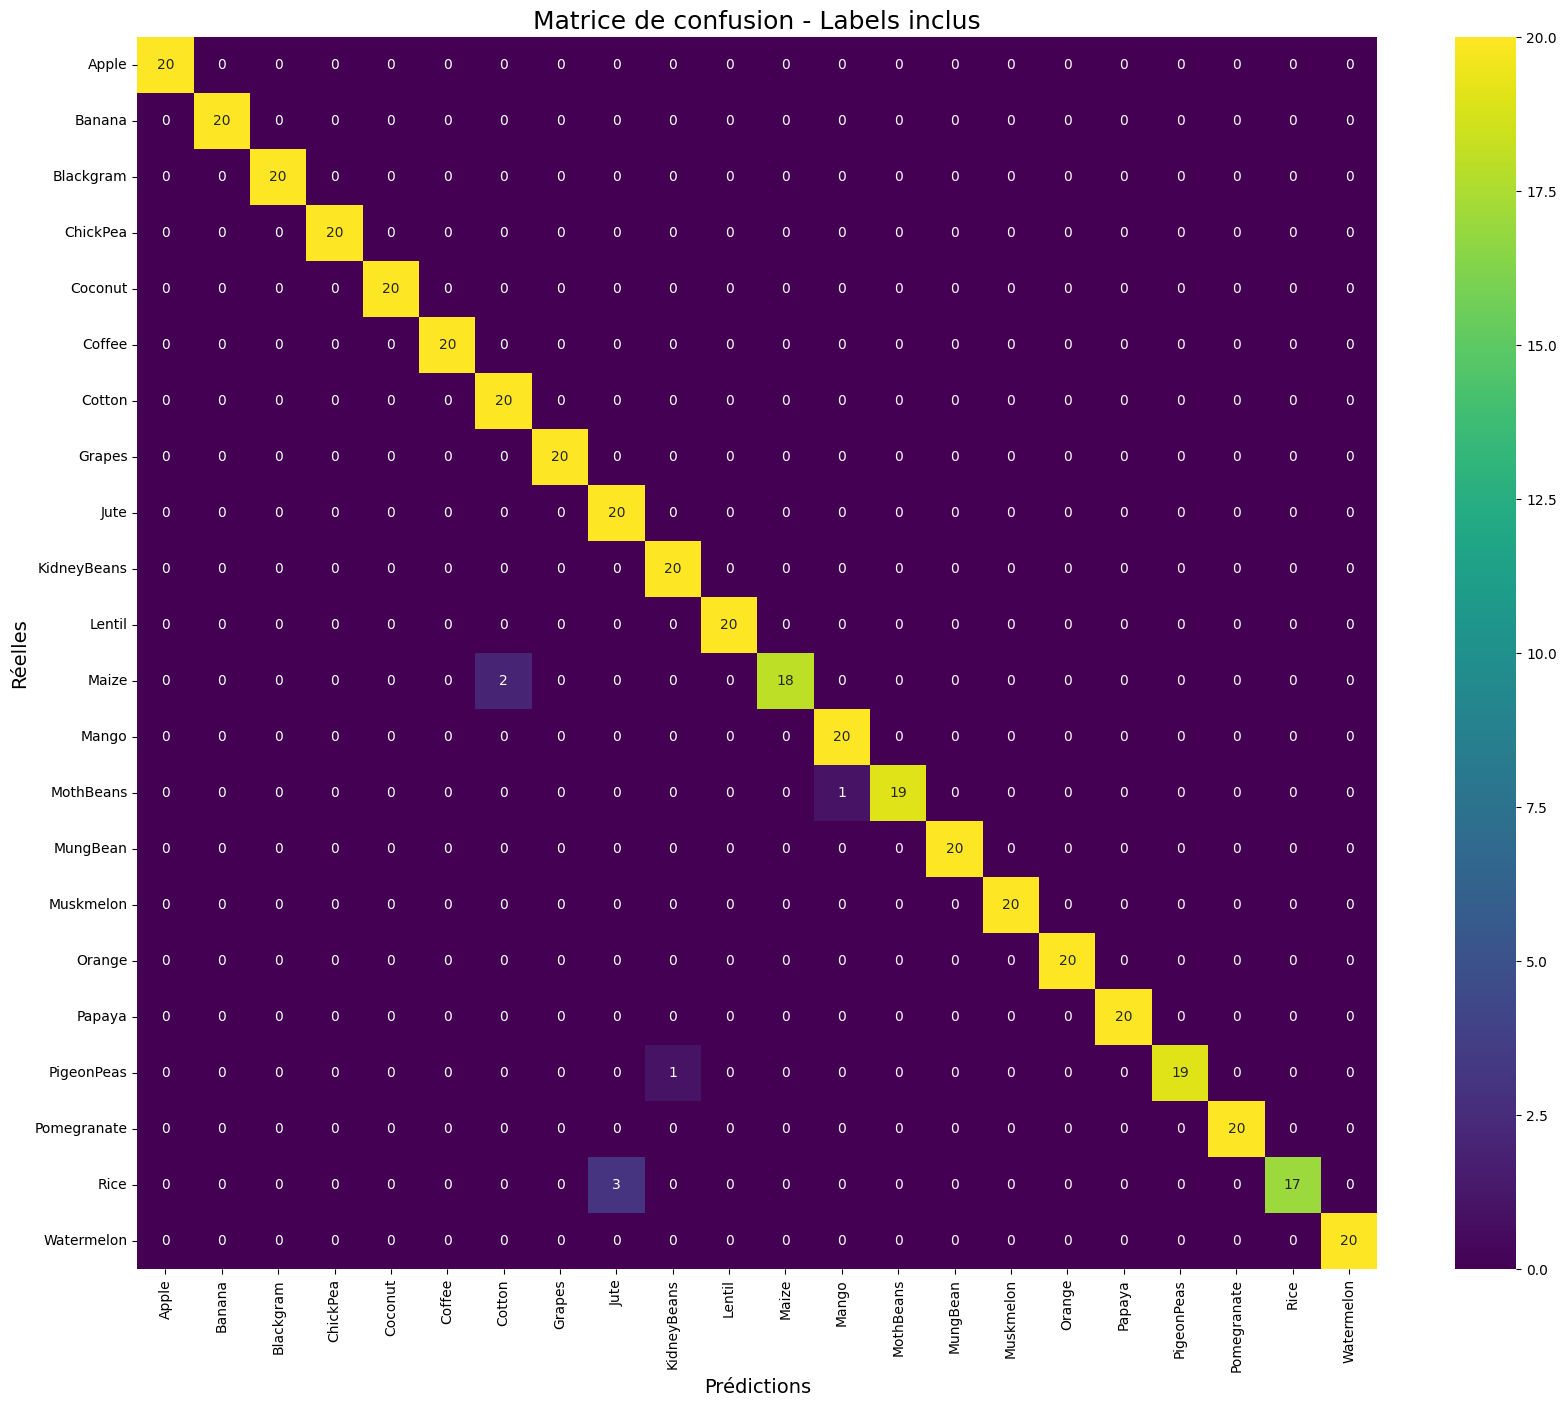

In [38]:
# ============================
#  SVM SANS PENALISATION + MATRICES DE CONFUSION
# ============================

# ----- 1. Entraînement du modèle (SVM Hard-Margin) -----

pipeline_hard = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())   # SVM SANS pénalisation
])

pipeline_hard.fit(X_train, y_train)
y_pred_hard = pipeline_hard.predict(X_test)

print("=======================================")
print("           SVM SANS PENALISATION       ")
print("=======================================")
print("\nAccuracy :", accuracy_score(y_test, y_pred_hard))
print("\nClassification report :\n", classification_report(y_test, y_pred_hard))


# ----- 2. Matrice de confusion -----

cm = confusion_matrix(y_test, y_pred_hard)
classes = sorted(y_test.unique())


# ----- 4. Affichage matrice brute avec labels -----

plt.figure(figsize=(20, 16))
sns.heatmap(
    cm, cmap="viridis", annot=True,
    xticklabels=classes, yticklabels=classes
)
plt.title("Matrice de confusion - Labels inclus", fontsize=18)
plt.xlabel("Prédictions", fontsize=14)
plt.ylabel("Réelles", fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

## Performance du SVM sans optimisation

Un premier modèle SVM a été entraîné avec les hyperparamètres par défaut (`SVC()`), afin d’établir une baseline avant l’étape de sélection de modèle.

### Résultats

- **Accuracy globale : 98.4 %**
- Les métriques par classe montrent que la grande majorité des cultures sont classées avec :
  - précision = 1.00
  - recall = 1.00
  - f1-score = 1.00

Ces performances confirment que les caractéristiques agro-climatiques (N, P, K, pH, température, humidité, pluie) possèdent une forte capacité discriminante pour identifier les cultures.

### Classes légèrement plus difficiles

Quelques classes présentent des scores légèrement plus faibles :

- `Rice` (f1 = 0.92),
- `Jute` (f1 = 0.93),
- `Maize` (f1 = 0.95),
- `Cotton` (f1 = 0.95).

Ces variations s’expliquent probablement par une plus grande similarité entre leurs profils environnementaux et ceux d’autres cultures.
## Matrice de confusion du SVM (baseline)

La matrice montre une **diagonale presque parfaite**, confirmant que le SVM sépare très bien les 22 cultures.  
Les rares confusions observées (surtout entre `Rice`, `Maize`, `Jute` et quelques légumineuses) concernent des classes aux profils agro-climatiques proches.

### Conclusion

Le SVM par défaut fournit déjà d’excellentes performances, montrant que le problème est bien structuré et que les données sont naturellement séparables.  
Une optimisation des hyperparamètres via **GridSearchCV** ou **RandomizedSearchCV** pourra encore affiner la séparation des classes les plus proches, mais les gains attendus seront modestes compte tenu du score déjà très élevé.


## Pipeline SVM + StandardScaler + ACP

In [39]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("svm", SVC())
])


## Grid Search pour optimiser C et gamma et les meilleurs axes principales 

In [40]:
param_grid = [
    {
        "pca__n_components": [5, 7],
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1, 10],
        "svm__gamma": [0.01, 0.1, 1]
    },
    {
        "pca__n_components": [5, 7],
        "svm__kernel": ["linear"],
        "svm__C": [0.1, 1, 10]
        # gamma ignoré automatiquement
    },
    {
        "pca__n_components": [5, 7],
        "svm__kernel": ["poly"],
        "svm__C": [0.1, 1, 10],
        "svm__gamma": [0.01, 0.1, 1],
        "svm__degree": [2, 3]
    }
]

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)


Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END pca__n_components=5, svm__C=0.1, svm__gamma=0.01, svm__kernel=rbf; total time=   0.1s
[CV] END pca__n_components=5, svm__C=0.1, svm__gamma=0.01, svm__kernel=rbf; total time=   0.1s
[CV] END pca__n_components=5, svm__C=0.1, svm__gamma=0.1, svm__kernel=rbf; total time=   0.1s
[CV] END pca__n_components=5, svm__C=0.1, svm__gamma=0.01, svm__kernel=rbf; total time=   0.1s
[CV] END pca__n_components=5, svm__C=0.1, svm__gamma=0.1, svm__kernel=rbf; total time=   0.1s
[CV] END pca__n_components=5, svm__C=0.1, svm__gamma=1, svm__kernel=rbf; total time=   0.1s
[CV] END pca__n_components=5, svm__C=0.1, svm__gamma=1, svm__kernel=rbf; total time=   0.1s
[CV] END pca__n_components=5, svm__C=0.1, svm__gamma=1, svm__kernel=rbf; total time=   0.1s
[CV] END pca__n_components=5, svm__C=0.1, svm__gamma=1, svm__kernel=rbf; total time=   0.1s
[CV] END pca__n_components=5, svm__C=0.1, svm__gamma=1, svm__kernel=rbf; total time=   0.1s
[CV] 

,estimator,"Pipeline(step...svm', SVC())])"
,param_grid,"[{'pca__n_components': [5, 7], 'svm__C': [0.1, 1, ...], 'svm__gamma': [0.01, 0.1, ...], 'svm__kernel': ['rbf']}, {'pca__n_components': [5, 7], 'svm__C': [0.1, 1, ...], 'svm__kernel': ['linear']}, ...]"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


## Recherche des meilleurs hyperparamètres (Pipeline + GridSearchCV)

Pour optimiser les performances du SVM, une recherche systématique des hyperparamètres a été réalisée à l’aide d’un pipeline combinant :

- Normalisation des données,
- Réduction de dimension (PCA),
- Modèle SVM avec différents kernels.

Le `GridSearchCV` a évalué **60 combinaisons** de paramètres en validation croisée (5-fold), soit **300 modèles** entraînés au total.  
Les paramètres explorés incluent :

- le nombre de composantes PCA (`n_components`),
- la pénalisation `C`,
- le coefficient du noyau RBF (`gamma`),
- le kernel (`rbf`, `linear`, `poly`),
- le degré du polynôme.

Cette étape permet d’identifier la configuration offrant la meilleure généralisation avant l’entraînement final du modèle.


## Meilleurs paramètres

In [41]:
print(grid.best_params_)
print(grid.best_score_)


{'pca__n_components': 7, 'svm__C': 1, 'svm__gamma': 1, 'svm__kernel': 'rbf'}
0.9869318181818182


## Meilleurs hyperparamètres du SVM (GridSearchCV)

La recherche systématique des paramètres via `GridSearchCV` a permis d’identifier la configuration offrant les meilleures performances.  
Les hyperparamètres optimaux obtenus sont :

- `pca__n_components = 7`
- `svm__kernel = 'rbf'`
- `svm__C = 1`
- `svm__gamma = 1`

Cette combinaison fournit une accuracy moyenne de **98.69 %** en validation croisée.  
Elle confirme que le noyau RBF, associé à une légère réduction de dimension (PCA), est la configuration la plus efficace pour distinguer les 22 cultures.


## Évaluation finale sur le test

In [42]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report :")
print(classification_report(y_test, y_pred))


Accuracy : 0.990909090909091

Classification Report :
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        20
      Banana       1.00      1.00      1.00        20
   Blackgram       1.00      1.00      1.00        20
    ChickPea       1.00      1.00      1.00        20
     Coconut       1.00      1.00      1.00        20
      Coffee       1.00      1.00      1.00        20
      Cotton       0.95      1.00      0.98        20
      Grapes       1.00      1.00      1.00        20
        Jute       0.91      1.00      0.95        20
 KidneyBeans       1.00      1.00      1.00        20
      Lentil       1.00      1.00      1.00        20
       Maize       1.00      0.95      0.97        20
       Mango       0.95      1.00      0.98        20
   MothBeans       1.00      0.95      0.97        20
    MungBean       1.00      1.00      1.00        20
   Muskmelon       1.00      1.00      1.00        20
      Orange       1.00    

##  Performances du SVM optimisé

Le modèle optimisé atteint une **accuracy de 99.09 %**, supérieure au SVM de base.  
Les métriques montrent une quasi-perfection pour l’ensemble des 22 cultures, avec une nette réduction des confusions observées précédemment (notamment pour `Rice`, `Maize`, `Jute`).  

Le tuning des hyperparamètres (RBF + C=1 + gamma=1 + PCA=7) améliore donc efficacement la précision du modèle.


## Matrice de confusion

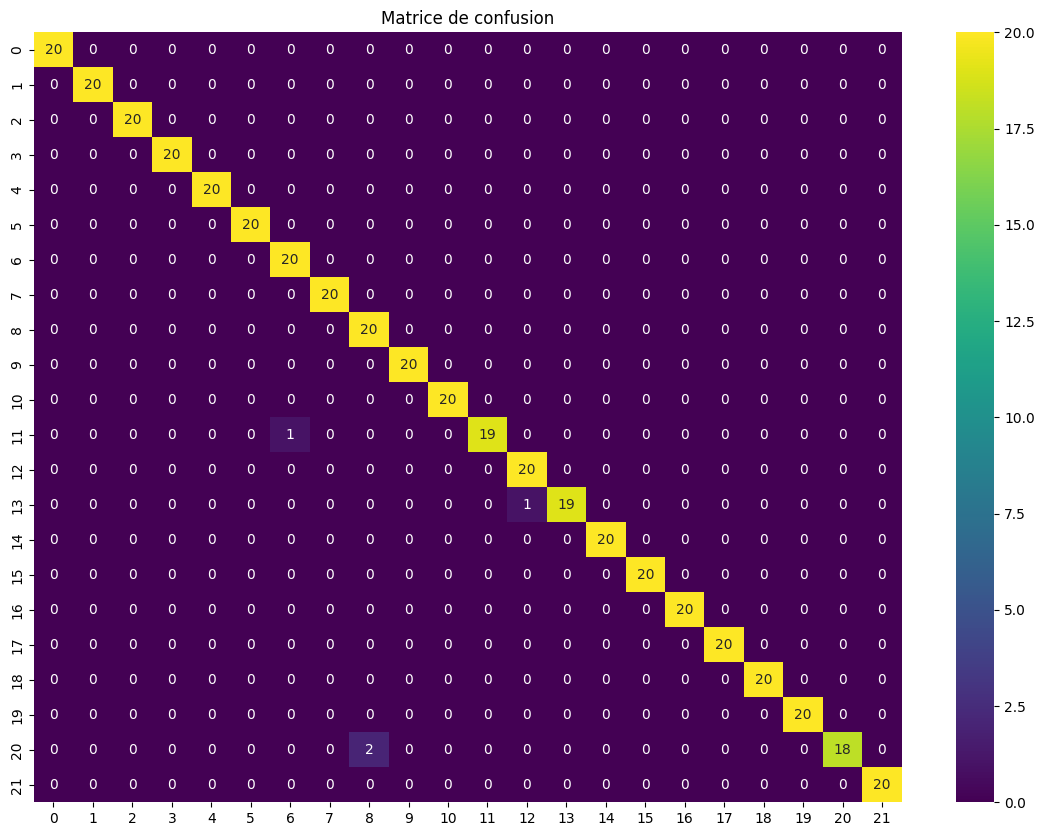

In [43]:
plt.figure(figsize=(14,10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="viridis")
plt.title("Matrice de confusion")
plt.show()


## Matrice de confusion du SVM optimisé

La matrice de confusion montre une **diagonale presque parfaite**, confirmant la très forte précision du modèle optimisé.  
Seules quelques erreurs isolées apparaissent, et elles concernent des classes aux caractéristiques très proches, déjà identifiées comme voisines dans la visualisation t-SNE.

### Conclusion
Le SVM optimisé corrige plusieurs confusions du modèle de base et atteint une séparation presque parfaite des 22 cultures.


## Sauvegarde du modèle

In [44]:
import joblib
joblib.dump(best_model, "svm_crop_model.pkl")

['svm_crop_model.pkl']

## Analyse

Ce projet vise à classifier 22 types de cultures agricoles à partir de variables agronomiques (N, P, K, température, humidité, pH et précipitations). Le dataset est parfaitement équilibré avec 100 échantillons par classe, ce qui garantit des métriques fiables et sans biais de distribution.

Une analyse exploratoire avancée, notamment via t-SNE 2D, révèle une structure **fortement non linéaire** des données : chaque culture forme un cluster compact et bien séparé. Ces visualisations montrent que les variables agronomiques contiennent une **information discriminante très élevée**, justifiant l’utilisation d’un classifieur non linéaire.

Un pipeline complet StandardScaler → PCA → SVM a été optimisé avec GridSearchCV. Le meilleur modèle obtenu est un **SVM à noyau RBF**, avec **PCA = 7 composantes**, **C = 1**, **gamma = 1**. Ce modèle atteint une accuracy remarquable de **≈ 99%**, confirmée par les matrices de confusion quasi parfaites.

L’ensemble des analyses démontre que la combinaison PCA + SVM-RBF est **très performante, stable et robuste** pour la recommandation de cultures. Le modèle généralise efficacement et sépare presque parfaitement les 22 classes.
